<a href="https://colab.research.google.com/github/Dexless/CSCI-164-Colab-Repo/blob/main/164Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from google.colab import userdata
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import sklearn
import kagglehub
import psycopg2
from psycopg2.extras import execute_values
import pandas as pd
import numpy as np
import os

In [60]:
## Kaggle Import of the dataset
ASTEROID_PATH = "/kaggle/input/asteroid-dataset"
NEOWS_PATH = "/kaggle/input/neows-hazardous-asteroid-dataset/NeoWS"

if(not (os.path.exists(ASTEROID_PATH) and os.path.exists(NEOWS_PATH))):
  a_ds = kagglehub.dataset_download("sakhawat18/asteroid-dataset")
  neo_ds = kagglehub.dataset_download("alvinb/neows-hazardous-asteroid-dataset")

## 0) Load all datasets into memory

In [61]:
DS_1 =  pd.read_csv(NEOWS_PATH + "/data_1900_1950_updated_December.csv", low_memory=False)
DS_2 =  pd.read_csv(NEOWS_PATH + "/data_1950_2000.csv", low_memory=False)
DS_3 =  pd.read_csv(NEOWS_PATH + "/data_1953_2000.csv", low_memory=False)
DS_4 =  pd.read_csv(NEOWS_PATH + "/data_2002_2022.csv", low_memory=False)
DS_5 =  pd.read_csv(NEOWS_PATH + "/data_2022_present.csv", low_memory=False)
asteroid_df = pd.read_csv(ASTEROID_PATH + "/dataset.csv", low_memory=False)
DS_LIST = [DS_1, DS_2, DS_3, DS_4, DS_5]
close_approach_df = pd.concat(DS_LIST, ignore_index=0)

# 1) Dataset Exploration & Pre-Processing

## 1.1) Listwise deletion based on threshold (80%>)

In [62]:
missing_summary_asteroid = pd.DataFrame({
  "column": asteroid_df.columns,
  "non_null_count": asteroid_df.notnull().sum().values,
  "missing_count": asteroid_df.isnull().sum().values,
  "missing_percent": (asteroid_df.isnull().mean().values * 100).round(2),
  "dtype": asteroid_df.dtypes.astype(str).values
})

missing_summary_asteroid.sort_values("missing_percent", ascending=False)

,column,non_null_count,missing_count,missing_percent,dtype
5,prefix,18,958506,100.00,object
4,name,22064,936460,97.70,object
10,albedo,135103,823421,85.91,float64
11,diameter_sigma,136081,822443,85.80,float64
9,diameter,136209,822315,85.79,float64
7,pha,938603,19921,2.08,object
42,sigma_per,938598,19926,2.08,float64
39,sigma_ad,938598,19926,2.08,float64
40,sigma_n,938602,19922,2.08,float64
35,sigma_i,938602,19922,2.08,float64


In [63]:
missing_summary_close_approach = pd.DataFrame({
  "column": close_approach_df.columns,
  "non_null_count": close_approach_df.notnull().sum().values,
  "missing_count": close_approach_df.isnull().sum().values,
  "missing_percent": (close_approach_df.isnull().mean().values * 100).round(2),
  "dtype": close_approach_df.dtypes.astype(str).values
})

missing_summary_close_approach.sort_values("missing_percent", ascending=False)


,column,non_null_count,missing_count,missing_percent,dtype
4,Absolute Magnitude,362691,26,0.01,float64
5,Est Dia in KM(min),362691,26,0.01,float64
8,Est Dia in M(max),362691,26,0.01,float64
9,Est Dia in Miles(min),362691,26,0.01,float64
7,Est Dia in M(min),362691,26,0.01,float64
6,Est Dia in KM(max),362691,26,0.01,float64
11,Est Dia in Feet(min),362691,26,0.01,float64
12,Est Dia in Feet(max),362691,26,0.01,float64
10,Est Dia in Miles(max),362691,26,0.01,float64
1,Date,362717,0,0.00,object


In [64]:
# Remove duplicates
asteroid_df = asteroid_df.drop_duplicates()
close_approach_df = close_approach_df.drop_duplicates()

# Remove all records with no values
asteroid_df = asteroid_df.dropna(axis = 0, how="all")
close_approach_df = close_approach_df.dropna(axis = 0, how="all")

# Remove all all features with no values
asteroid_df = asteroid_df.dropna(axis = 1, how="all")
close_approach_df = close_approach_df.dropna(axis = 1, how="all")

In [65]:
T = 80

cols_to_drop_asteroid = missing_summary_asteroid[missing_summary_asteroid["missing_percent"] > T]["column"].tolist()
cols_to_drop_asteroid

['name', 'prefix', 'diameter', 'albedo', 'diameter_sigma']

In [66]:
cols_to_drop_close_approach = missing_summary_close_approach[missing_summary_close_approach["missing_percent"] > T]["column"].tolist()
cols_to_drop_close_approach

[]

In [67]:
asteroid_df = asteroid_df.drop(columns=cols_to_drop_asteroid)
close_approach_df = close_approach_df.drop(columns=cols_to_drop_close_approach)

## 1.2) Pairwise Deletion

In [68]:
asteroid_df = asteroid_df.dropna(subset=["pha"])

## 1.3) Dropping identification features

In [69]:
asteroid_identifiers = ["id", "full_name", "pdes", "orbit_id"] # "spkid"
close_approach_identifiers = ["Unnamed: 0", "Name", "Orbit ID", "Orbit Determination Date", "Equinox"] # "Neo Reference ID"

asteroid_df = asteroid_df.drop(axis=1, labels=asteroid_identifiers)
close_approach_df = close_approach_df.drop(axis=1, labels=close_approach_identifiers)

## 1.4) Feature Transformation: One-Hot Encoding

In [70]:
# Fill with key->value pairs of cols that are np.dtype object
# this will be used for OHE
asteroid_feats = {}
close_approach_feats = {}

# Iterate through object columns in asteroid_df
for col in asteroid_df.select_dtypes(include=["object"]).columns:
  s = set()
  for unique in asteroid_df[col].dropna():
    s.add(unique)
  asteroid_feats[col] = s

# Iterate through object columns in close_approach_df
for col in close_approach_df.select_dtypes(include=["object"]).columns:
  s = set()
  for unique in close_approach_df[col].dropna():
    s.add(unique)
  close_approach_feats[col] = s

print(asteroid_feats)

for key, value in close_approach_feats.items():
  print(f"{key}: {list(value)[:5]}")

{'neo': {'N', 'Y'}, 'pha': {'N', 'Y'}, 'equinox': {'J2000'}, 'class': {'AMO', 'HYA', 'IMB', 'MBA', 'OMB', 'APO', 'IEO', 'AST', 'MCA', 'TNO', 'TJN', 'ATE', 'CEN'}}
Date: ['1907-01-28', '1995-03-14', '1905-03-13', '1949-02-21', '1909-08-09']
Close Approach Date: ['1993-09-10', '1938-01-06', '2018-09-27', '1996-02-07', '2000-05-03']
Orbiting Body: ['Earth']


In [71]:
# Don't encode just map to 1/0
asteroid_df["neo"] = asteroid_df["neo"].map({"Y": 1, "N": 0})
asteroid_df["pha"] = asteroid_df["pha"].map({"Y": 1, "N": 0})

# Since 'equinox' and 'orbiting body' cols only have one value it has little
# Analytical meaning so we drop it
asteroid_df = asteroid_df.drop(columns=["equinox"])
close_approach_df = close_approach_df.drop(columns=["Orbiting Body"])

In [72]:
# Since we have many dates as unique values we will convert
# them to a datetime object which will allow us to extract more meaning from them
close_approach_df["Date"] = pd.to_datetime(close_approach_df["Date"])

# Converting date to new features based on year/month/day/dayofyear (0-364/5)
close_approach_df["year"] = close_approach_df["Date"].dt.year
close_approach_df["month"] = close_approach_df["Date"].dt.month
close_approach_df["day"] = close_approach_df["Date"].dt.day
close_approach_df["day_of_year"] = close_approach_df["Date"].dt.dayofyear

# Date no longer needed
close_approach_df = close_approach_df.drop(columns=["Date"])

In [73]:
close_approach_df["Close Approach Date"] = pd.to_datetime(close_approach_df["Close Approach Date"])

close_approach_df["approach_year"] = close_approach_df["Close Approach Date"].dt.year
close_approach_df["approach_month"] = close_approach_df["Close Approach Date"].dt.month
close_approach_df["approach_day"] = close_approach_df["Close Approach Date"].dt.day
close_approach_df["approach_day_of_year"] = close_approach_df["Close Approach Date"].dt.dayofyear

close_approach_df = close_approach_df.drop(columns=["Close Approach Date"])

In [74]:
asteroid_df = asteroid_df.reset_index(drop=True)

onehot_encoder = OneHotEncoder(sparse_output=False)

class_labels = pd.DataFrame(
  onehot_encoder.fit_transform(asteroid_df[["class"]]),
  columns=["AMO", "APO", "AST", "ATE", "CEN", "HYA", "IEO", "IMB", "MBA", "MCA", "OMB", "TJN", "TNO"],
)

asteroid_df = asteroid_df.join(class_labels)
asteroid_df = asteroid_df.drop(columns=["class"])

asteroid_df

,spkid,neo,pha,H,epoch,epoch_mjd,epoch_cal,e,a,q,...,ATE,CEN,HYA,IEO,IMB,MBA,MCA,OMB,TJN,TNO
0,2000001,0.0,0,3.400,2458600.5,58600,20190427.0,0.076009,2.769165,2.558684,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,2000002,0.0,0,4.200,2459000.5,59000,20200531.0,0.229972,2.773841,2.135935,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,2000003,0.0,0,5.330,2459000.5,59000,20200531.0,0.256936,2.668285,1.982706,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,2000004,0.0,0,3.000,2458600.5,58600,20190427.0,0.088721,2.361418,2.151909,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,2000005,0.0,0,6.900,2459000.5,59000,20200531.0,0.190913,2.574037,2.082619,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938598,3246801,0.0,0,17.135,2437203.5,37203,19600926.0,0.185919,2.280861,1.856807,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
938599,3246834,0.0,0,18.500,2459000.5,59000,20200531.0,0.282920,2.334910,1.674319,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
938600,3013075,1.0,1,20.400,2459000.5,59000,20200531.0,0.662446,2.817152,0.950941,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
938601,3246457,0.0,0,18.071,2441956.5,41956,19731001.0,0.202053,2.373137,1.893638,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## 1.5) Redundant Measurement Deletion

In [75]:
redundant_close_cols = [
"Relative Velocity km per sec",
"Miles per hour",
"Miss Dist.(Astronomical)",
"Miss Dist.(lunar)",
"Miss Dist.(miles)",
"Est Dia in M(min)",
"Est Dia in M(max)",
"Est Dia in Miles(min)",
"Est Dia in Miles(max)",
"Est Dia in Feet(min)",
"Est Dia in Feet(max)"]

close_approach_df = close_approach_df.drop(columns=redundant_close_cols)

## 1.6) Stratified Sampling, Train/Validation/Test Split, and Median Imputation

In [76]:
ASTEROID_SAMPLE_SIZE = 30000
CLOSE_SAMPLE_SIZE = 30000

In [77]:
y_asteroid = asteroid_df["pha"]
X_asteroid = asteroid_df.drop(columns=["pha", "spkid"], errors="ignore")

if len(X_asteroid) > ASTEROID_SAMPLE_SIZE:
  X_asteroid, _, y_asteroid, _ = train_test_split(X_asteroid, y_asteroid, train_size=ASTEROID_SAMPLE_SIZE, random_state=0, stratify=y_asteroid)

X_asteroid_train, X_asteroid_temp, y_asteroid_train, y_asteroid_temp = train_test_split(X_asteroid, y_asteroid, test_size=0.2, random_state=0, stratify=y_asteroid)
X_asteroid_valid, X_asteroid_test, y_asteroid_valid, y_asteroid_test = train_test_split(X_asteroid_temp, y_asteroid_temp, test_size=0.5, random_state=0, stratify=y_asteroid_temp)

asteroid_imputer = SimpleImputer(strategy="median")

X_asteroid_train = asteroid_imputer.fit_transform(X_asteroid_train)
X_asteroid_valid = asteroid_imputer.transform(X_asteroid_valid)
X_asteroid_test = asteroid_imputer.transform(X_asteroid_test)

In [78]:
y_close = close_approach_df["Hazardous"]
X_close = close_approach_df.drop(columns=["Hazardous", "Neo Reference ID"], errors="ignore")

if len(X_close) > CLOSE_SAMPLE_SIZE:
  X_close, _, y_close, _ = train_test_split(X_close, y_close, train_size=CLOSE_SAMPLE_SIZE, random_state=0, stratify=y_close)

X_close_train, X_close_temp, y_close_train, y_close_temp = train_test_split(X_close, y_close, test_size=0.2, random_state=0, stratify=y_close)
X_close_valid, X_close_test, y_close_valid, y_close_test = train_test_split(X_close_temp, y_close_temp, test_size=0.5, random_state=0, stratify=y_close_temp)

close_imputer = SimpleImputer(strategy="median")

X_close_train = close_imputer.fit_transform(X_close_train)
X_close_valid = close_imputer.transform(X_close_valid)
X_close_test = close_imputer.transform(X_close_test)

# 2. Model Development with scikit-learn

## 2.1 Feature Scaling


In [79]:
asteroid_scaler = StandardScaler()

X_asteroid_train = asteroid_scaler.fit_transform(X_asteroid_train)
X_asteroid_valid = asteroid_scaler.transform(X_asteroid_valid)
X_asteroid_test = asteroid_scaler.transform(X_asteroid_test)

close_scaler = StandardScaler()

X_close_train = close_scaler.fit_transform(X_close_train)
X_close_valid = close_scaler.transform(X_close_valid)
X_close_test = close_scaler.transform(X_close_test)

## 2.2 Define Models


In [80]:
asteroid_models = {
"Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=0),
"KNN": KNeighborsClassifier(n_neighbors=5),
"MLP": MLPClassifier(hidden_layer_sizes=(50,), max_iter=300, random_state=0)}

close_models = {
"Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=0),
"KNN": KNeighborsClassifier(n_neighbors=5),
"MLP": MLPClassifier(hidden_layer_sizes=(50,), max_iter=300, random_state=0)}

## 2.3 Create Evaluation Function

In [81]:
def evaluate_model(model, X_train, y_train, X_valid, y_valid) -> dict: # Take in model and train/valid return scores
  model.fit(X_train, y_train)
  y_pred = model.predict(X_valid)

  y_prob = model.predict_proba(X_valid)[:, 1]
  roc_auc = roc_auc_score(y_valid, y_prob)

  return {
    "accuracy": accuracy_score(y_valid, y_pred),
    "precision": precision_score(y_valid, y_pred, zero_division=0),
    "recall": recall_score(y_valid, y_pred, zero_division=0),
    "f1": f1_score(y_valid, y_pred, zero_division=0),
    "roc_auc": roc_auc
  }

## 2.4 Train Baseline Models on the Asteroid Dataset

In [82]:
asteroid_results = {}

for name, model in asteroid_models.items():
  asteroid_results[name] = evaluate_model(model, X_asteroid_train, y_asteroid_train, X_asteroid_valid, y_asteroid_valid)

asteroid_results_df = pd.DataFrame(asteroid_results).T
asteroid_results_df

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.990333,0.194444,1.0,0.325581,0.996277
KNN,0.997000,0.000000,0.0,0.000000,0.783280
MLP,0.997000,0.000000,0.0,0.000000,0.994988


## 2.5 Asteroid Dataset Classification Reports

In [83]:
for name, model in asteroid_models.items():
  y_pred = model.predict(X_asteroid_valid)

  print(name)
  print(confusion_matrix(y_asteroid_valid, y_pred))
  print()

Logistic Regression
[[2964   29]
 [   0    7]]

KNN
[[2991    2]
 [   7    0]]

MLP
[[2991    2]
 [   7    0]]



## 2.6 Train Baseline Models on the Close-Approach Dataset

In [84]:
close_results = {}

for name, model in close_models.items():
  close_results[name] = evaluate_model(model, X_close_train, y_close_train, X_close_valid, y_close_valid)

close_results_df = pd.DataFrame(close_results).T
close_results_df

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.937667,0.687616,0.953846,0.799141,0.989513
KNN,0.907333,0.701439,0.500000,0.583832,0.917464
MLP,0.992000,0.966837,0.971795,0.969309,0.999519


## 2.7 Close-Approach Dataset Classification Reports

In [85]:
for name, model in close_models.items():
  y_pred = model.predict(X_close_valid)

  print(name)
  print(confusion_matrix(y_close_valid, y_pred))
  print()

Logistic Regression
[[2441  169]
 [  18  372]]

KNN
[[2527   83]
 [ 195  195]]

MLP
[[2597   13]
 [  11  379]]



## 2.8 Baseline Model Comparison

In [86]:
asteroid_results_df["dataset"] = "Asteroid"
close_results_df["dataset"] = "Close Approach"

baseline_results_df = pd.concat([asteroid_results_df, close_results_df])
baseline_results_df

,accuracy,precision,recall,f1,roc_auc,dataset
Logistic Regression,0.990333,0.194444,1.000000,0.325581,0.996277,Asteroid
KNN,0.997000,0.000000,0.000000,0.000000,0.783280,Asteroid
MLP,0.997000,0.000000,0.000000,0.000000,0.994988,Asteroid
Logistic Regression,0.937667,0.687616,0.953846,0.799141,0.989513,Close Approach
KNN,0.907333,0.701439,0.500000,0.583832,0.917464,Close Approach
MLP,0.992000,0.966837,0.971795,0.969309,0.999519,Close Approach


# 3. Hyperparameter Tuning and Model Comparison

## 3.1 Define Tuned Model Options

In [87]:
scoring_metric = "f1" # Better for unbalanced sets
cv_folds = 3

## 3.3) Hyperparameter Grids (LOG/KNN/MLP)

In [88]:
log_reg_params = {"C": [0.01, 0.1, 1, 10]}
knn_params = {"n_neighbors": [3, 5, 7],"weights": ["uniform", "distance"]}
mlp_params = {"hidden_layer_sizes": [(25,), (50,)], "alpha": [0.0001, 0.001]}

## 3.4) Tune Logistic Regression / KNN / MLP on the Asteroid Dataset

In [89]:
asteroid_log_reg_grid = GridSearchCV(LogisticRegression(max_iter=1000, class_weight="balanced", random_state=0), log_reg_params, scoring=scoring_metric, cv=cv_folds)
asteroid_log_reg_grid.fit(X_asteroid_train, y_asteroid_train)

print("Best parameters:", asteroid_log_reg_grid.best_params_)
print("Best CV score:", asteroid_log_reg_grid.best_score_)

asteroid_knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, scoring=scoring_metric, cv=cv_folds)
asteroid_knn_grid.fit(X_asteroid_train, y_asteroid_train)

print("Best parameters:", asteroid_knn_grid.best_params_)
print("Best CV score:", asteroid_knn_grid.best_score_)

asteroid_mlp_grid = GridSearchCV(MLPClassifier(max_iter=150, early_stopping=True, random_state=0), mlp_params, scoring=scoring_metric, cv=cv_folds)
asteroid_mlp_grid.fit(X_asteroid_train, y_asteroid_train)

print("Best parameters:", asteroid_mlp_grid.best_params_)
print("Best CV score:", asteroid_mlp_grid.best_score_)


Best parameters: {'C': 10}
Best CV score: 0.3552700092382632
Best parameters: {'n_neighbors': 3, 'weights': 'uniform'}
Best CV score: 0.26733143399810066
Best parameters: {'alpha': 0.0001, 'hidden_layer_sizes': (50,)}
Best CV score: 0.1384126984126984


## 3.5) Evaluate Tuned Asteroid Models on the Validation Set

In [90]:
asteroid_tuned_models = {"Logistic Regression": asteroid_log_reg_grid.best_estimator_,"KNN": asteroid_knn_grid.best_estimator_,"MLP": asteroid_mlp_grid.best_estimator_}

asteroid_tuned_results = {}

for name, model in asteroid_tuned_models.items():
  y_pred = model.predict(X_asteroid_valid)
  y_prob = model.predict_proba(X_asteroid_valid)[:, 1]

  asteroid_tuned_results[name] = {
    "accuracy": accuracy_score(y_asteroid_valid, y_pred),
    "precision": precision_score(y_asteroid_valid, y_pred, zero_division=0),
    "recall": recall_score(y_asteroid_valid, y_pred, zero_division=0),
    "f1": f1_score(y_asteroid_valid, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_asteroid_valid, y_prob)
  }

asteroid_tuned_results_df = pd.DataFrame(asteroid_tuned_results).T
asteroid_tuned_results_df

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.992333,0.233333,1.0,0.378378,0.997948
KNN,0.996667,0.000000,0.0,0.000000,0.783590
MLP,0.997333,0.000000,0.0,0.000000,0.350294


## 3.6) Tune Logistic Regression / KNN / MLP on the Close-Approach Dataset

In [91]:
close_log_reg_grid = GridSearchCV(LogisticRegression(max_iter=1000, class_weight="balanced", random_state=0), log_reg_params, scoring=scoring_metric, cv=cv_folds)
close_log_reg_grid.fit(X_close_train, y_close_train)

print("Best parameters:", close_log_reg_grid.best_params_)
print("Best CV score:", close_log_reg_grid.best_score_)

close_knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, scoring=scoring_metric, cv=cv_folds)
close_knn_grid.fit(X_close_train, y_close_train)

print("Best parameters:", close_knn_grid.best_params_)
print("Best CV score:", close_knn_grid.best_score_)

close_mlp_grid = GridSearchCV(MLPClassifier(max_iter=150, early_stopping=True, random_state=0), mlp_params, scoring=scoring_metric, cv=cv_folds)
close_mlp_grid.fit(X_close_train, y_close_train)

print("Best parameters:", close_mlp_grid.best_params_)
print("Best CV score:", close_mlp_grid.best_score_)

Best parameters: {'C': 10}
Best CV score: 0.7820849511465832
Best parameters: {'n_neighbors': 3, 'weights': 'distance'}
Best CV score: 0.5542868489521192
Best parameters: {'alpha': 0.0001, 'hidden_layer_sizes': (25,)}
Best CV score: 0.9670779757904832


## 3.7) Evaluate Tuned Close-Approach Models on the Validation Set

In [92]:
close_tuned_models = {"Logistic Regression": close_log_reg_grid.best_estimator_,"KNN": close_knn_grid.best_estimator_,"MLP": close_mlp_grid.best_estimator_}

close_tuned_results = {}

for name, model in close_tuned_models.items():
  y_pred = model.predict(X_close_valid)
  y_prob = model.predict_proba(X_close_valid)[:, 1]

  close_tuned_results[name] = {
  "accuracy": accuracy_score(y_close_valid, y_pred),
  "precision": precision_score(y_close_valid, y_pred, zero_division=0),
  "recall": recall_score(y_close_valid, y_pred, zero_division=0),
  "f1": f1_score(y_close_valid, y_pred, zero_division=0),
  "roc_auc": roc_auc_score(y_close_valid, y_prob)}

close_tuned_results_df = pd.DataFrame(close_tuned_results).T # Flip it, it looks better flipped
close_tuned_results_df

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.938000,0.688889,0.953846,0.800000,0.989484
KNN,0.908667,0.680124,0.561538,0.615169,0.889105
MLP,0.991333,0.955000,0.979487,0.967089,0.999179


## 3.8) Compare Tuned Results Across Datasets

In [93]:
asteroid_tuned_results_df["dataset"] = "Asteroid"
close_tuned_results_df["dataset"] = "Close Approach"

tuned_results_df = pd.concat([asteroid_tuned_results_df, close_tuned_results_df])
tuned_results_df

,accuracy,precision,recall,f1,roc_auc,dataset
Logistic Regression,0.992333,0.233333,1.000000,0.378378,0.997948,Asteroid
KNN,0.996667,0.000000,0.000000,0.000000,0.783590,Asteroid
MLP,0.997333,0.000000,0.000000,0.000000,0.350294,Asteroid
Logistic Regression,0.938000,0.688889,0.953846,0.800000,0.989484,Close Approach
KNN,0.908667,0.680124,0.561538,0.615169,0.889105,Close Approach
MLP,0.991333,0.955000,0.979487,0.967089,0.999179,Close Approach


## 3.9) Plot Tuned Model Results

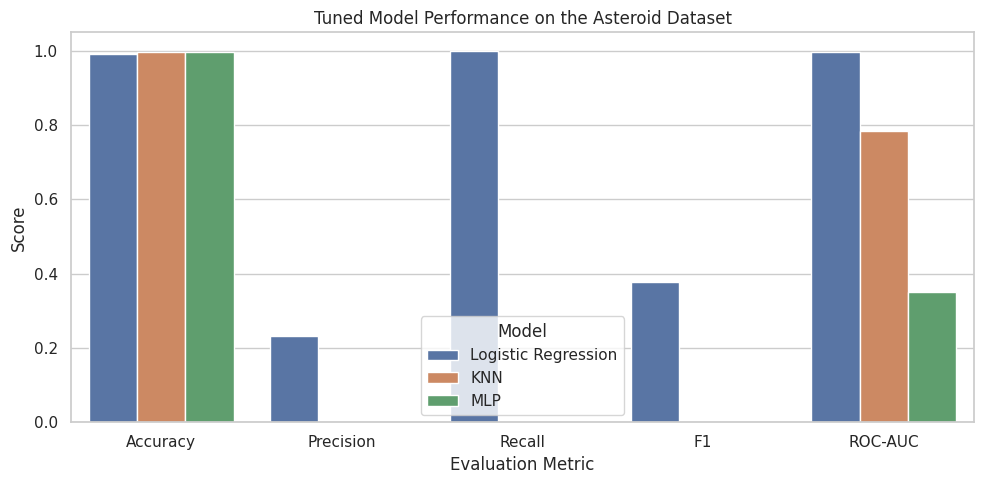

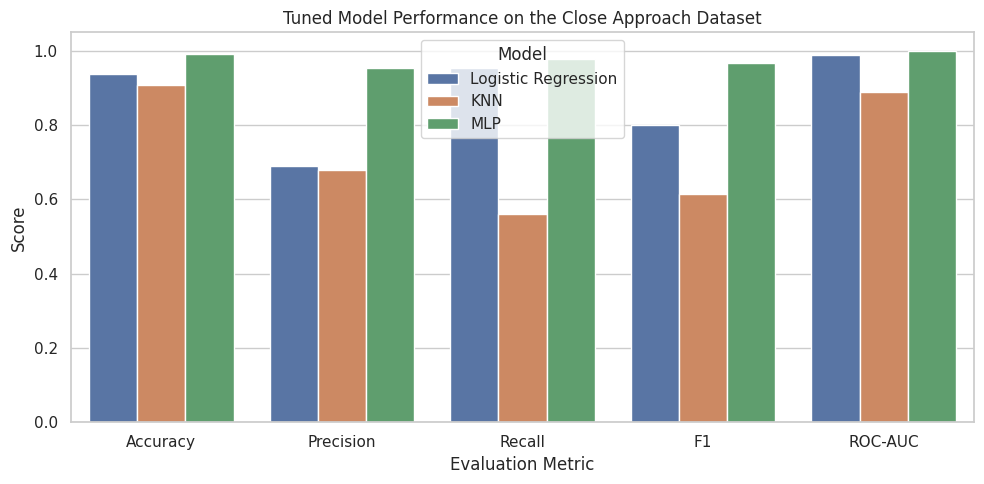

In [94]:
sns.set_theme(style="whitegrid")
tuned_plot_df = tuned_results_df.reset_index().rename(columns={"index": "model"})

tuned_plot_long = tuned_plot_df.melt(
id_vars=["model", "dataset"],
value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"],
var_name="metric",
value_name="score"
)

tuned_plot_long["metric"] = tuned_plot_long["metric"].replace({
"accuracy": "Accuracy",
"precision": "Precision",
"recall": "Recall",
"f1": "F1",
"roc_auc": "ROC-AUC"
})

for dataset_name in tuned_plot_long["dataset"].unique():
  dataset_metrics = tuned_plot_long[tuned_plot_long["dataset"] == dataset_name]

  plt.figure(figsize=(10, 5))
  sns.barplot(data=dataset_metrics, x="metric", y="score", hue="model")

  plt.title(f"Tuned Model Performance on the {dataset_name} Dataset")
  plt.xlabel("Evaluation Metric")
  plt.ylabel("Score")
  plt.ylim(0, 1.05)
  plt.legend(title="Model")
  plt.tight_layout()
  plt.show()

## 3.9) Select Best Tuned Models

In [95]:
best_asteroid_model_name = asteroid_tuned_results_df["f1"].idxmax()
best_close_model_name = close_tuned_results_df["f1"].idxmax()

best_asteroid_model = asteroid_tuned_models[best_asteroid_model_name]
best_close_model = close_tuned_models[best_close_model_name]

print("Best astaroid model:", best_asteroid_model_name)
print("Best close-approach model:", best_close_model_name)

Best astaroid model: Logistic Regression
Best close-approach model: MLP
